In [65]:
from utilsforecast.preprocessing import fill_gaps
from tinyshift.stats import remove_leading_zeros, is_obsolete
from tinyshift.plot import stationarity_analysis, pami, residual_analysis, seasonal_decompose
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from statsmodels.tsa.seasonal import MSTL
from statsforecast.models import SeasonalNaive, AutoETS
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, bias, cfe
from tinyshift.modelling import DMSTLWrapper, fourier_seasonality
from mlforecast.utils import PredictionIntervals
from tinyshift.series import wape, pbias, score, forecast_instability, detect_seasonal_periods, extract_mstl_components, fva_rmae, mach

In [66]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df["unique_id"] = "1"
df.rename(columns={"Month": "ds", "Passengers": "y"}, inplace=True)
df = fill_gaps(df, freq="ME", end="per_serie", id_col="unique_id", time_col="ds")
df = df.groupby("unique_id")[df.columns].apply(remove_leading_zeros).reset_index(drop=True)
df = fourier_seasonality(df, "ds", seasonality=["monthly"])
days_obsoletes=180
obsolete_series = df.groupby("unique_id")[df.columns].apply(is_obsolete, days_obsoletes)
obsolote_ids = obsolete_series[obsolete_series].index.tolist()
assert len(obsolote_ids) == 0, f"Obsolete series found: {obsolote_ids}"

In [67]:
metrics = [rmse, mae, bias, wape, pbias, score, forecast_instability]

In [68]:
df.isnull().sum()

unique_id      0
ds             0
y              0
monthly_sin    0
monthly_cos    0
dtype: int64

## MSTL + ML

In [69]:
horizon = 12
train = df[:-horizon]
test = df[-horizon:]

In [70]:
periods = detect_seasonal_periods(df["y"], top_k=2, noise_threshold_factor=2.0)

In [71]:
periods

[6, 12]

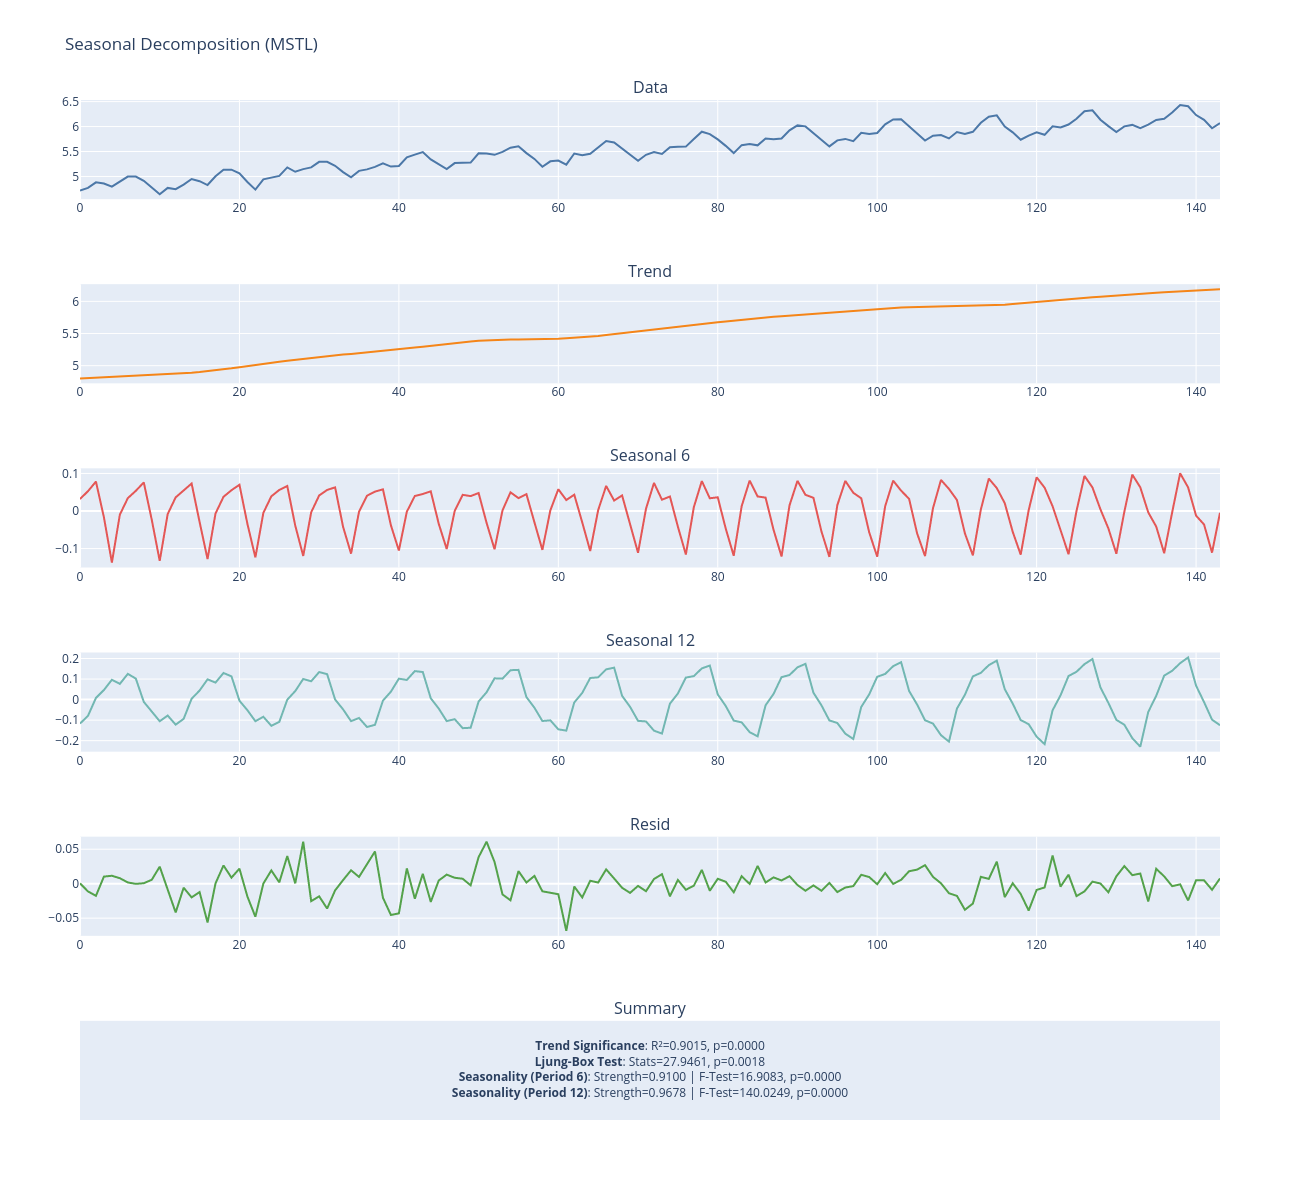

In [72]:
seasonal_decompose(np.log(df["y"]),periods=periods,fig_type="png")

In [73]:
#def compute_lgbm_params(N: int):
#    max_depth = int(np.ceil(np.log2(N) - 1))
#    subsample_freq = 1
#    colsample_bytree = 0.7
#    n_estimators = 1000
#    reg_lambda = 0.2
#    reg_alpha = 0.2
#    metric = "mae"
#    learning_rate = 0.05
#    min_child_samples = max(20, int(np.cbrt(N)))
#    n_jobs = -1
#    random_state = 42
#
#    return {
#        "max_depth": int(max_depth),
#        "subsample_freq": subsample_freq,
#        "colsample_bytree": colsample_bytree,
#        "n_estimators": n_estimators,
#        "metric": metric,
#        "learning_rate": learning_rate,
#        "num_leaves": 40,
#        "min_child_samples": min_child_samples,
#        "reg_alpha": reg_alpha,
#        "reg_lambda": reg_lambda,
#        "objective": "regression_l2",
#        "n_jobs": n_jobs,
#        "random_state": random_state
#    }
#models = [LGBMRegressor(n_estimators=1000, random_state=42), RandomForestRegressor(n_estimators=100, random_state=42)]
#config = compute_lgbm_params(len(train))
models = [LinearRegression(), RandomForestRegressor(n_estimators=100, random_state=42)]

In [74]:
mstl = MSTL(train["y"], periods=periods).fit()
decomp = extract_mstl_components(mstl, periods)

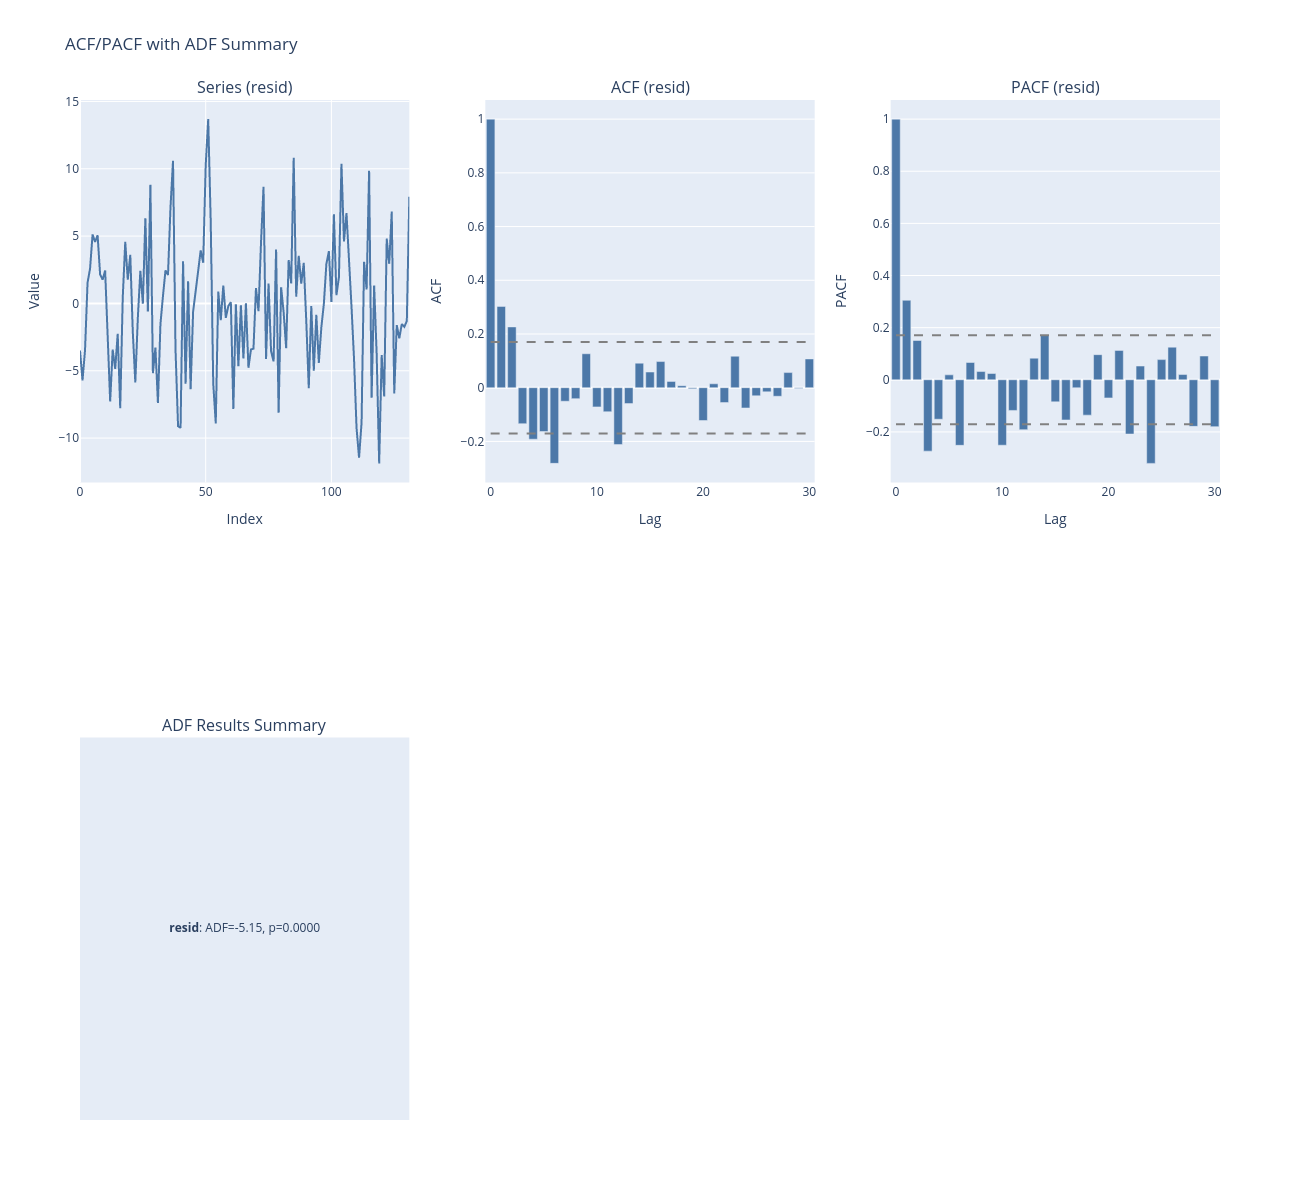

In [75]:
stationarity_analysis(decomp["resid"], nlags=30, fig_type="png")

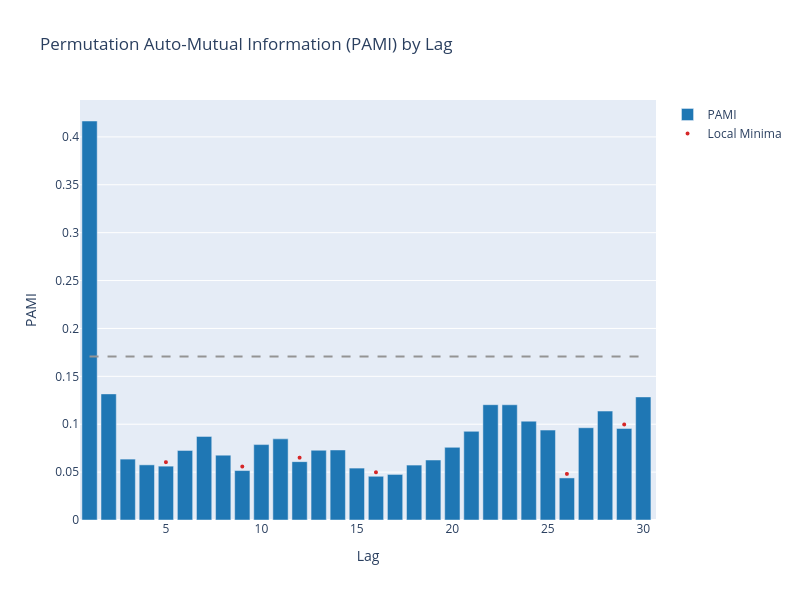

In [76]:
pami(decomp["resid"], nlags=30, fig_type="png", m=3, normalize=True)

In [77]:
def callable_seasonal(period):
    return AutoETS(
        season_length=period,
        model="ZNA",
        alias=f"AutoETS-{period}",
    )

def callable_trend():
    return AutoETS(
        model="ZAN",
        alias="Trend-AutoETS",
    )

season_length = 12
mf = MLForecast(
    models=models,
    freq="MS",
    lags=[1, 5],
)
dmstl = DMSTLWrapper(
    mf_resid=mf,
    season_length=periods,
    trend_model_callable=callable_trend,
    seasonal_model_callable=callable_seasonal,
)


In [78]:
dmstl.fit(train[["unique_id", "ds", "y"]], target_col="y")

,mf_resid,MLForecast(mo...num_threads=1)
,season_length,"[6, 12]"
,trend_model_callable,<function cal...x76ae6e377eb0>
,seasonal_model_callable,<function cal...x76ae6e3775b0>
,log_transform,False


In [79]:
result = dmstl.predict(h=12)
result["y"] = test["y"].values

In [80]:
evaluate(result, 
         metrics=metrics, 
         models=["LinearRegression", "RandomForestRegressor"], 
         id_col="unique_id", 
         time_col="ds", 
         target_col="y")

,unique_id,metric,LinearRegression,RandomForestRegressor
0,1,rmse,18.853033,20.442186
1,1,mae,15.326620,15.884758
2,1,bias,10.275310,11.591380
3,1,wape,3.218751,3.335966
4,1,pbias,2.157923,2.434311
5,1,score,5.376674,5.770277
6,1,forecast_instability,9.269926,9.150201


In [81]:
result["residual_dmstl_lr"] = result["y"].values - result["LinearRegression"].values
result["residual_dmstl_rf"] = result["y"].values - result["RandomForestRegressor"].values

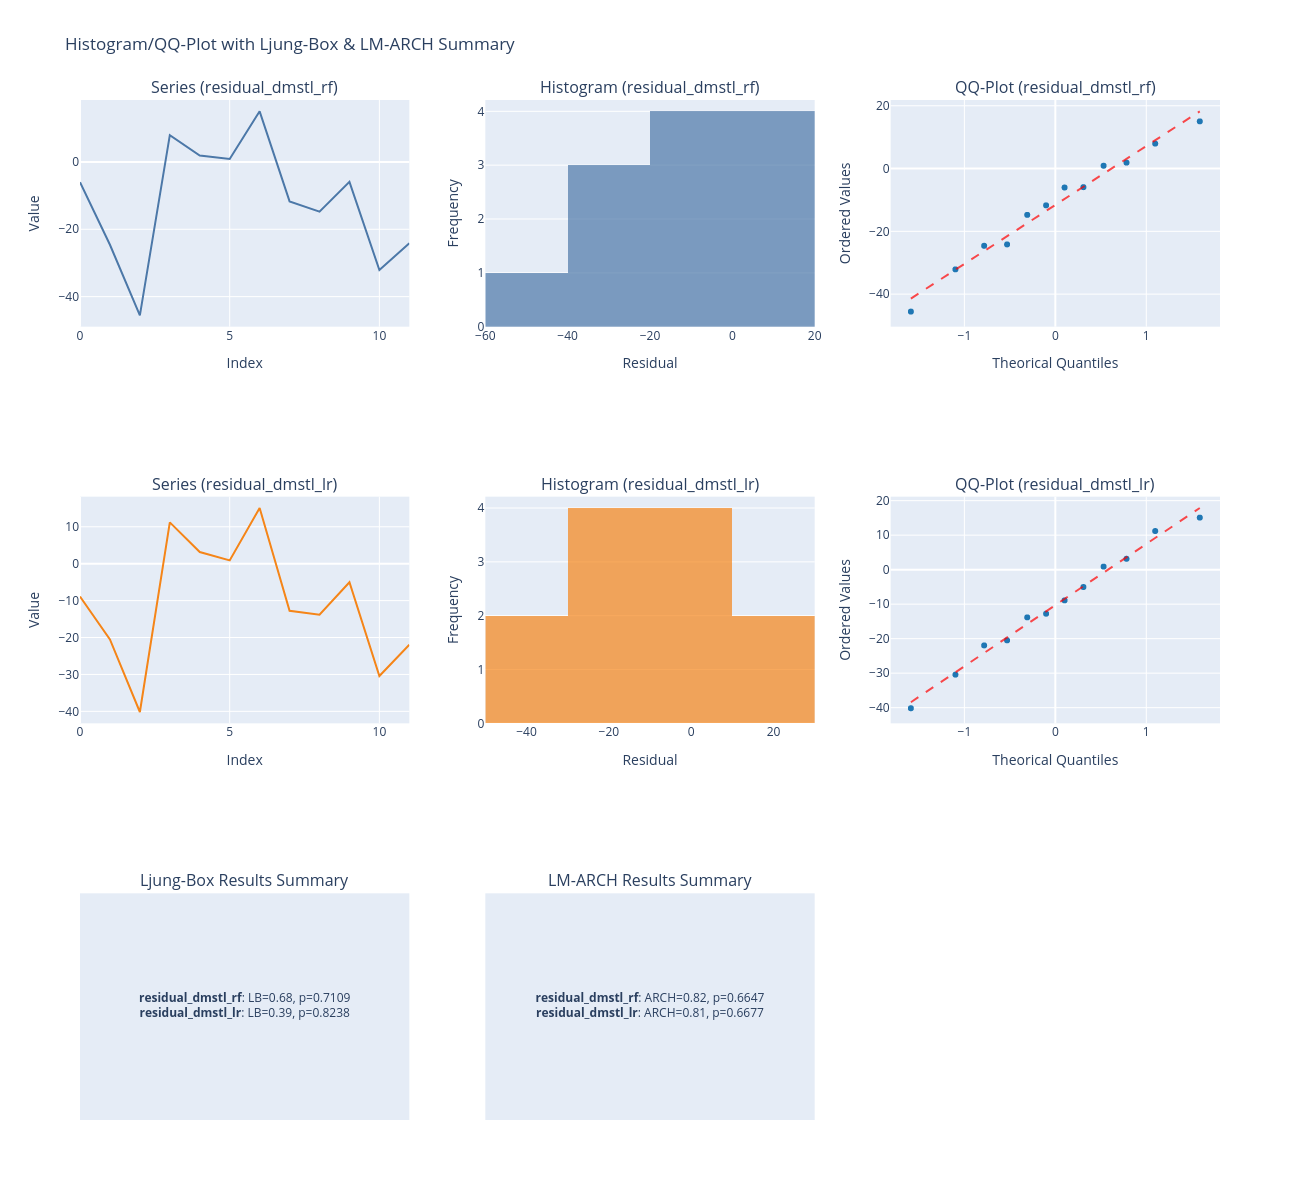

In [82]:
residual_analysis(result[["residual_dmstl_rf", "residual_dmstl_lr"]], nlags=30, fig_type="png")

## Horizontal Partial Interpolation

In [83]:
result["y_pred_pi"] = dmstl.predict(h=12, stabilization_method="hpi", w_s=0.8)["RandomForestRegressor"]
mac_h_result = mach(result["y_pred_pi"])
print(f"MAC(H) (Horizontal Stability): {mac_h_result:.6f}")

MAC(H) (Horizontal Stability): 34.621336


## Horizontal Full Interpolation

In [84]:
result["y_pred_fi"] = dmstl.predict(h=12, stabilization_method="hfi", w_s=0.8)["RandomForestRegressor"]
mac_h_result = mach(result["y_pred_fi"])
print(f"MAC(H) (Horizontal Stability): {mac_h_result:.6f}")

MAC(H) (Horizontal Stability): 11.845382


In [85]:
fva_rmae(result["y"].values, result["RandomForestRegressor"].values, nlags=1, baseline_type="naive")

0.34760171166111026

In [86]:
fva_rmae(result["y"].values, result["RandomForestRegressor"].values, baseline_type="moving_average", window_size=3)

0.24233239679481344

# Prediction Intervals

In [87]:
periods

[6, 12]

In [88]:
def callable_autoets(period):
    return AutoETS(
        season_length=period,
        model="ZNA",
        alias=f"AutoETS-{period}",
    )

prediction_intervals = PredictionIntervals(
    n_windows=3,
    h=14,
)
dmstl = DMSTLWrapper(
    mf_resid=mf,
    season_length=periods,
    seasonal_model_callable=callable_autoets,
)
dmstl.fit(
    train[["unique_id", "ds", "y"]],
    target_col="y",
    prediction_intervals=prediction_intervals,
)
forecasts = dmstl.predict(
    h=14,
    level=[95],
)


In [89]:
result = dmstl.predict(h=12)
result["y"] = test["y"].values

In [90]:
evaluate(result,
         metrics=metrics,
         models=["RandomForestRegressor"],
         id_col="unique_id",
         time_col="ds",
         target_col="y")

,unique_id,metric,RandomForestRegressor
0,1,rmse,20.442186
1,1,mae,15.884758
2,1,bias,11.591380
3,1,wape,3.335966
4,1,pbias,2.434311
5,1,score,5.770277
6,1,forecast_instability,9.150201


## Per-SKU Seasonal Periods with DMSTLWrapper

`DMSTLWrapper` accepts a dictionary when different series require different seasonal periods. Each key must match a `unique_id`, and each value can be a single period or a list of periods.

The first configuration below is explicit. The second one uses `detect_seasonal_periods` on the complete panel and passes its per-SKU result directly to `DMSTLWrapper`.


In [91]:
panel = pd.concat(
    [
        train.assign(unique_id="sku-a"),
        train.assign(unique_id="sku-b"),
    ],
    ignore_index=True,
)

manual_season_lengths = {
    "sku-a": [7, 30],
    "sku-b": 12,
}
trend_model_callable = {
    "sku-a": lambda: AutoETS(model="ZZN", alias="Trend-sku-a"),
    "sku-b": lambda: AutoETS(model="ZNN", alias="Trend-sku-b"),
}
manual_dmstl = DMSTLWrapper(
    mf_resid=mf,
    season_length=manual_season_lengths,
    trend_model_callable=trend_model_callable,
)
manual_dmstl.fit(panel[["unique_id", "ds", "y"]], target_col="y")

manual_season_lengths


{'sku-a': [7, 30], 'sku-b': 12}

In [92]:
manual_dmstl.fitted_models_

{'sku-a': {'trend': StatsForecast(models=[Trend-sku-a]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-7]),
   StatsForecast(models=[SeasonalNaive-30])],
  'residual': MLForecast(models=[LinearRegression, RandomForestRegressor], freq=MS, lag_features=['lag1', 'lag5'], date_features=[], num_threads=1)},
 'sku-b': {'trend': StatsForecast(models=[Trend-sku-b]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-12])],
  'residual': MLForecast(models=[LinearRegression, RandomForestRegressor], freq=MS, lag_features=['lag1', 'lag5'], date_features=[], num_threads=1)}}

In [93]:
detected_season_lengths = detect_seasonal_periods(
    panel,
    top_k=2,
    target_col="y",
)

In [94]:
seasonal_model_callable = {
    "sku-a": lambda period: AutoETS(
        season_length=period,
        model="ZNA",
        alias=f"AutoETS-{period}",
    ),
    "sku-b": lambda period: SeasonalNaive(
        season_length=period,
        alias=f"SeasonalNaive-{period}",
    ),
}
detected_dmstl = DMSTLWrapper(
    mf_resid=mf,
    season_length=detected_season_lengths,
    seasonal_model_callable=seasonal_model_callable,
)
detected_dmstl.fit(panel[["unique_id", "ds", "y"]], target_col="y", prediction_intervals=prediction_intervals)

detected_season_lengths


{'sku-a': [6, 12], 'sku-b': [6, 12]}

In [95]:
detected_dmstl.predict(h=12, level=[95])

,unique_id,ds,LinearRegression,RandomForestRegressor,LinearRegression-lo-95,LinearRegression-hi-95,RandomForestRegressor-lo-95,RandomForestRegressor-hi-95
0,sku-a,1960-01-01,425.904497,423.040588,416.495731,435.313263,414.141236,431.939941
1,sku-a,1960-02-01,411.501287,415.599371,400.398797,422.603778,398.676967,432.521775
2,sku-a,1960-03-01,459.171643,464.551089,452.409966,465.933319,458.201768,470.900410
3,sku-a,1960-04-01,449.804051,453.055525,442.800853,456.807248,446.075838,460.035213
4,sku-a,1960-05-01,468.847335,470.106878,464.566024,473.128646,467.708538,472.505218
5,sku-a,1960-06-01,534.122174,534.103508,529.816046,538.428302,527.739711,540.467306
6,sku-a,1960-07-01,606.918584,606.973819,597.997587,615.839580,594.087205,619.860434
7,sku-a,1960-08-01,618.765708,617.715962,607.839884,629.691532,605.666404,629.765521
8,sku-a,1960-09-01,521.833966,522.750874,513.685466,529.982466,512.242065,533.259683
9,sku-a,1960-10-01,466.035057,466.926470,462.301540,469.768575,466.389199,467.463740


Comparativo agregado robusto (limite por SKU calculado no treino):


,MAE,RMSE,actual_total,forecast_total,total_error_pct
portfolio_aggregate_robust,882.268542,1066.213088,30913.0,48322.47101,56.317637


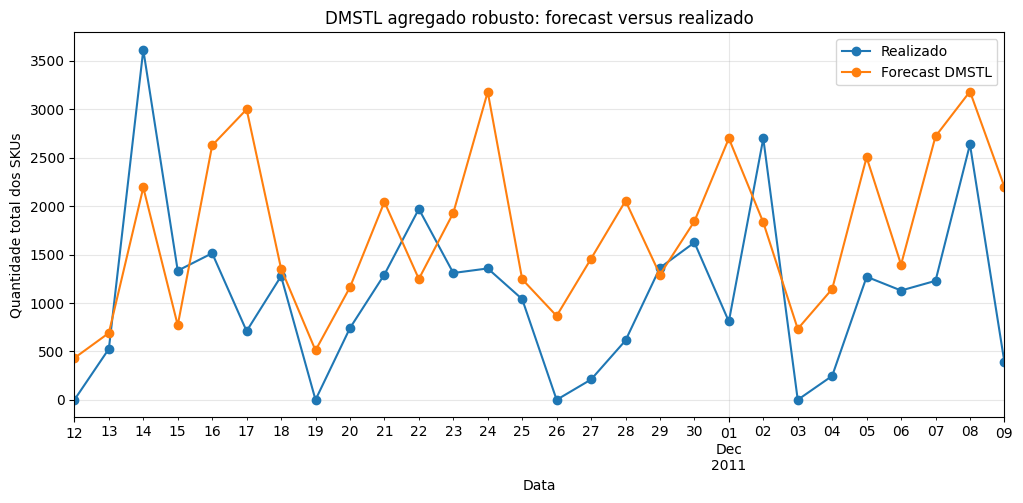

,y,forecast
ds,,
2011-11-12,0.0,431.822564
2011-11-13,526.0,690.296790
2011-11-14,3615.0,2193.318738
2011-11-15,1334.0,770.134503
2011-11-16,1514.0,2627.888219
2011-11-17,710.0,3000.605508
2011-11-18,1277.0,1354.819963
2011-11-19,0.0,510.730583
2011-11-20,741.0,1162.166207


In [99]:
# Comparativo agregado robusto: remove o efeito de pedidos atacadistas extremos.
robust_values = (
    retail_agg.groupby(["StockCode", "ds"])["Quantity"]
    .sum()
    .rename("y")
    .reset_index()
    .rename(columns={"StockCode": "unique_id"})
)
robust_values["unique_id"] = robust_values["unique_id"].astype(str)
robust_dates = pd.date_range(retail_agg["ds"].min(), retail_agg["ds"].max(), freq="D")
robust_panel = pd.MultiIndex.from_product(
    [top_skus_dmstl, robust_dates], names=["unique_id", "ds"]
).to_frame(index=False)
robust_panel = robust_panel.merge(
    robust_values, on=["unique_id", "ds"], how="left"
)
robust_panel["y"] = robust_panel["y"].fillna(0.0)

robust_horizon = horizon_agg
robust_cutoff = robust_panel["ds"].max() - pd.Timedelta(days=robust_horizon)
robust_train = robust_panel[robust_panel["ds"] <= robust_cutoff].copy()
robust_test = robust_panel[robust_panel["ds"] > robust_cutoff].copy()
upper_bounds = robust_train.groupby("unique_id")["y"].quantile(0.995)
robust_train["y"] = robust_train.apply(
    lambda row: min(row["y"], upper_bounds[row["unique_id"]]), axis=1
)
robust_test["y"] = robust_test.apply(
    lambda row: min(row["y"], upper_bounds[row["unique_id"]]), axis=1
)

robust_dmstl = DMSTLWrapper(
    mf_resid=MLForecast(
        models=[RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)],
        freq="D",
        lags=[1, 7, 14, 28],
    ),
    season_length=[7, 30],
    trend_model_callable=callable_trend,
    seasonal_model_callable=callable_seasonal,
)
robust_dmstl.fit(robust_train, target_col="y")
robust_forecast = robust_dmstl.predict(h=robust_horizon).rename(
    columns={"RandomForestRegressor": "forecast"}
)
robust_comparison = robust_test.merge(
    robust_forecast[["unique_id", "ds", "forecast"]],
    on=["unique_id", "ds"],
)
robust_comparison["forecast"] = robust_comparison["forecast"].clip(lower=0)
robust_aggregate = robust_comparison.groupby("ds")[["y", "forecast"]].sum()
robust_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(robust_aggregate["y"], robust_aggregate["forecast"])],
        "RMSE": [mean_squared_error(robust_aggregate["y"], robust_aggregate["forecast"]) ** 0.5],
        "actual_total": [robust_aggregate["y"].sum()],
        "forecast_total": [robust_aggregate["forecast"].sum()],
    },
    index=["portfolio_aggregate_robust"],
)
robust_metrics["total_error_pct"] = 100 * (
    robust_metrics["forecast_total"] / robust_metrics["actual_total"] - 1
)

print("Comparativo agregado robusto (limite por SKU calculado no treino):")
display(robust_metrics)
ax = robust_aggregate.plot(figsize=(12, 5), marker="o")
ax.set_title("DMSTL agregado robusto: forecast versus realizado")
ax.set_xlabel("Data")
ax.set_ylabel("Quantidade total dos SKUs")
ax.legend(["Realizado", "Forecast DMSTL"])
ax.grid(alpha=0.3)
plt.show()

robust_aggregate

Protocolo comum: 12 SKUs | corte temporal: 80% | horizonte: 28 dias


,MAE,RMSE,actual_total,forecast_total,total_error_pct
dmstl_same_protocol,891.820873,1442.864917,28932.0,36527.123231,26.251636


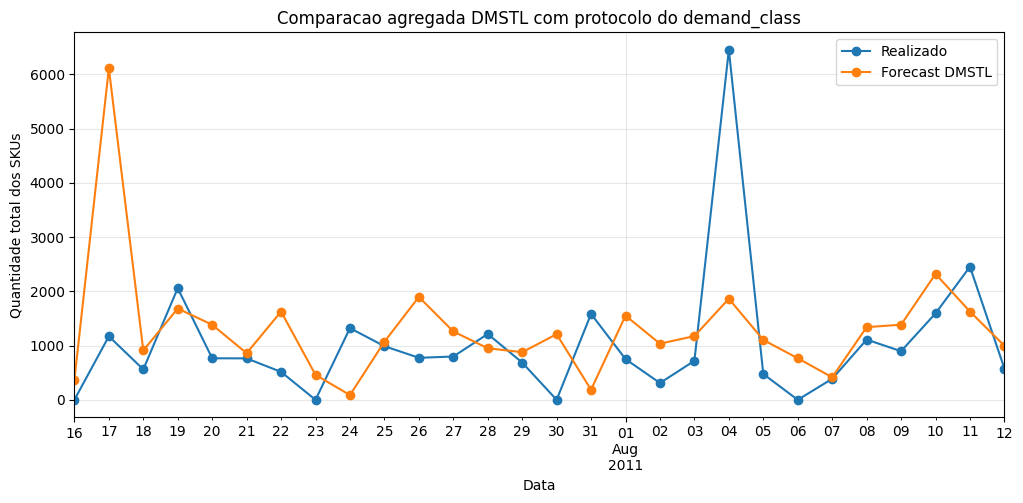

,y,forecast
ds,,
2011-07-16,0.0,368.544939
2011-07-17,1171.0,6112.565725
2011-07-18,561.0,909.436493
2011-07-19,2058.0,1683.161649
2011-07-20,766.0,1383.981682
2011-07-21,764.0,859.255234
2011-07-22,515.0,1627.435510
2011-07-23,0.0,460.554271
2011-07-24,1322.0,87.248918


In [100]:
# Benchmark DMSTL com o mesmo protocolo do demand_class.
benchmark_skus = (
    retail.groupby("StockCode")["Quantity"]
    .sum()
    .nlargest(12)
    .index
    .astype(str)
    .tolist()
)
benchmark_retail = retail[retail["StockCode"].isin(benchmark_skus)].copy()
benchmark_dates = pd.date_range(
    benchmark_retail["ds"].min(), benchmark_retail["ds"].max(), freq="D"
)
benchmark_panel = pd.MultiIndex.from_product(
    [benchmark_dates, benchmark_skus], names=["ds", "unique_id"]
).to_frame(index=False)
benchmark_values = (
    benchmark_retail.groupby(["ds", "StockCode"])["Quantity"]
    .sum()
    .rename("y")
    .reset_index()
    .rename(columns={"StockCode": "unique_id"})
)
benchmark_panel = benchmark_panel.merge(
    benchmark_values, on=["ds", "unique_id"], how="left"
)
benchmark_panel["y"] = benchmark_panel["y"].fillna(0.0)

benchmark_cutoff = benchmark_panel["ds"].quantile(0.80)
benchmark_train = benchmark_panel[benchmark_panel["ds"] <= benchmark_cutoff].copy()
benchmark_test = benchmark_panel[benchmark_panel["ds"] > benchmark_cutoff].copy()
benchmark_horizon = 28

benchmark_dmstl = DMSTLWrapper(
    mf_resid=MLForecast(
        models=[RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)],
        freq="D",
        lags=[1, 7, 14, 28],
    ),
    season_length=[7, 30],
    trend_model_callable=callable_trend,
    seasonal_model_callable=callable_seasonal,
)
benchmark_dmstl.fit(benchmark_train, target_col="y")
benchmark_forecast = benchmark_dmstl.predict(h=benchmark_horizon).rename(
    columns={"RandomForestRegressor": "forecast"}
)
benchmark_comparison = benchmark_test.merge(
    benchmark_forecast[["unique_id", "ds", "forecast"]],
    on=["unique_id", "ds"],
)
benchmark_comparison["forecast"] = benchmark_comparison["forecast"].clip(lower=0)
benchmark_aggregate = benchmark_comparison.groupby("ds")[["y", "forecast"]].sum()
benchmark_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(benchmark_aggregate["y"], benchmark_aggregate["forecast"])],
        "RMSE": [mean_squared_error(benchmark_aggregate["y"], benchmark_aggregate["forecast"]) ** 0.5],
        "actual_total": [benchmark_aggregate["y"].sum()],
        "forecast_total": [benchmark_aggregate["forecast"].sum()],
    },
    index=["dmstl_same_protocol"],
)
benchmark_metrics["total_error_pct"] = 100 * (
    benchmark_metrics["forecast_total"] / benchmark_metrics["actual_total"] - 1
)

print(f"Protocolo comum: {len(benchmark_skus)} SKUs | corte temporal: 80% | horizonte: {benchmark_horizon} dias")
display(benchmark_metrics)
ax = benchmark_aggregate.plot(figsize=(12, 5), marker="o")
ax.set_title("Comparacao agregada DMSTL com protocolo do demand_class")
ax.set_xlabel("Data")
ax.set_ylabel("Quantidade total dos SKUs")
ax.legend(["Realizado", "Forecast DMSTL"])
ax.grid(alpha=0.3)
plt.show()

benchmark_aggregate

Periodos detectados por SKU:


84077      [7, 30]
85099B      [4, 7]
21212       [2, 7]
85123A      [4, 7]
22197       [2, 7]
84879     [7, 197]
23843          [7]
23166          [7]
17003       [3, 4]
21977       [5, 7]
84991       [3, 7]
22492       [4, 7]
Name: season_length, dtype: object

Comparacao agregada no mesmo protocolo do demand_class:


,MAE,RMSE,actual_total,forecast_total,total_error_pct
DMSTL_periodos_fixos_7_30,891.820873,1442.864917,28932.0,36527.123231,26.251636
DMSTL_periodos_detectados,680.810539,1150.694385,28932.0,26241.925429,-9.297921


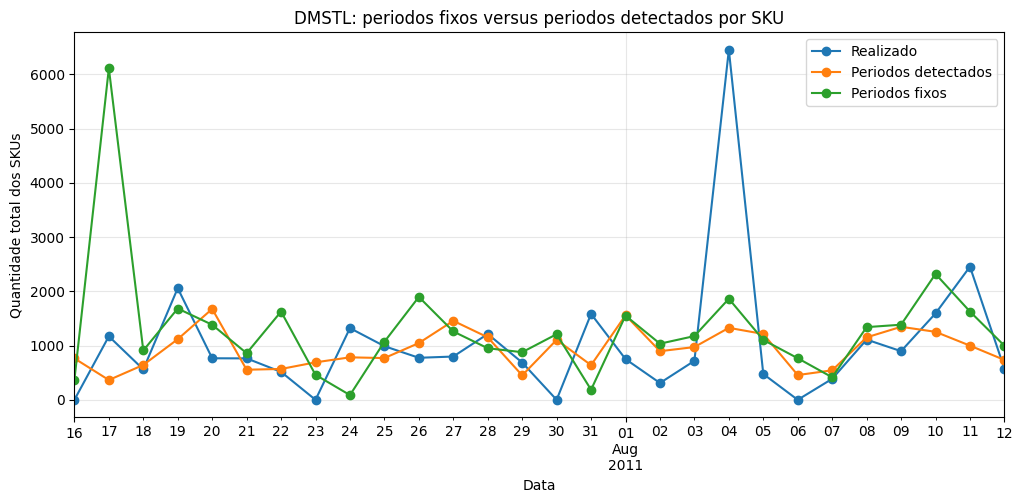

,y,forecast_periodos_detectados,forecast_periodos_fixos
ds,,,
2011-07-16,0.0,763.874768,368.544939
2011-07-17,1171.0,365.154251,6112.565725
2011-07-18,561.0,642.814866,909.436493
2011-07-19,2058.0,1117.874390,1683.161649
2011-07-20,766.0,1676.178258,1383.981682
2011-07-21,764.0,554.946174,859.255234
2011-07-22,515.0,568.949517,1627.435510
2011-07-23,0.0,691.011112,460.554271
2011-07-24,1322.0,783.508654,87.248918


In [106]:
# DMSTL com periodos sazonais detectados individualmente para cada SKU.
detected_periods_by_sku = detect_seasonal_periods(
    benchmark_train,
    unique_id_col="unique_id",
    target_col="y",
    top_k=2,
)
for uid, group in benchmark_train.groupby("unique_id"):
    detected_periods_by_sku[uid] = [
        period
        for period in detected_periods_by_sku.get(uid, [])
        if period > 1 and period <= len(group) // 2
    ] or [7]

dmstl_detected = DMSTLWrapper(
    mf_resid=MLForecast(
        models=[RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)],
        freq="D",
        lags=[1, 7, 14, 28],
    ),
    season_length=detected_periods_by_sku,
    trend_model_callable=callable_trend,
    seasonal_model_callable=callable_seasonal,
)
dmstl_detected.fit(benchmark_train, target_col="y")
forecast_detected = dmstl_detected.predict(h=benchmark_horizon).rename(
    columns={"RandomForestRegressor": "forecast_detected"}
)
comparison_detected = benchmark_test.merge(
    forecast_detected[["unique_id", "ds", "forecast_detected"]],
    on=["unique_id", "ds"],
)
comparison_detected["forecast_detected"] = comparison_detected["forecast_detected"].clip(lower=0)
detected_aggregate = comparison_detected.groupby("ds")[["y", "forecast_detected"]].sum()

metrics_detected = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(detected_aggregate["y"], detected_aggregate["forecast_detected"])],
        "RMSE": [mean_squared_error(detected_aggregate["y"], detected_aggregate["forecast_detected"]) ** 0.5],
        "actual_total": [detected_aggregate["y"].sum()],
        "forecast_total": [detected_aggregate["forecast_detected"].sum()],
    },
    index=["DMSTL_periodos_detectados"],
)
metrics_detected["total_error_pct"] = 100 * (
    metrics_detected["forecast_total"] / metrics_detected["actual_total"] - 1
)

comparison_fixed = benchmark_metrics.rename(index={"dmstl_same_protocol": "DMSTL_periodos_fixos_7_30"})
comparison_metrics_periods = pd.concat([comparison_fixed, metrics_detected])
print("Periodos detectados por SKU:")
display(pd.Series(detected_periods_by_sku, name="season_length"))
print("Comparacao agregada no mesmo protocolo do demand_class:")
display(comparison_metrics_periods)

plot_periods = detected_aggregate.rename(columns={"forecast_detected": "forecast_periodos_detectados"})
plot_periods["forecast_periodos_fixos"] = benchmark_aggregate["forecast"]
ax = plot_periods.plot(figsize=(12, 5), marker="o")
ax.set_title("DMSTL: periodos fixos versus periodos detectados por SKU")
ax.set_xlabel("Data")
ax.set_ylabel("Quantidade total dos SKUs")
ax.legend(["Realizado", "Periodos detectados", "Periodos fixos"])
ax.grid(alpha=0.3)
plt.show()

plot_periods